# Chapter project - Forecasting Armenian electricity production

**Lectures [30] and [31], one problem, start to finish.**

Every model in this course so far assumed the rows were interchangeable. This one does not.

### The question

> Given monthly electricity production in Armenia through **December 2024**,
> forecast **each month of 2025**.

That is a **12-month horizon**, and saying it out loud matters: a method that wins at 1 month
ahead can lose badly at 12. Every number below is measured at this one horizon, on this one
test window, so the comparisons are fair.

### The data

`data/armstat_electricity_monthly.csv`, from the Statistical Committee of Armenia
(ArmStatBank table `IC-ind-m-01.px`, activity `35. Electricity, gas, steam and air conditioning
supply`). Volume of industrial production, **current prices**, thousand drams.

Re-fetch it any time with `py_src/fetch_armstat_electricity.py`.

### The plan

| Part | What we do | From |
|---|---|---|
| 1 | Audit the data before modelling anything | - |
| 2 | Decompose: trend, seasonality, noise | [30] |
| 3 | Stationarity, differencing, reading ACF/PACF | [30] |
| 4 | **Baseline first**, MASE by hand | [30] |
| 5 | SARIMA and Holt-Winters | [30] |
| 6 | Forecasting as supervised learning | [31] |
| 7 | The extrapolation trap | [31] |
| 8 | Honest comparison at one horizon | [31] |
| 9 | Verdict | - |

## Setup

Thread-capped on purpose: this is a laptop, and nothing here needs more than a few cores.

In [1]:
import os
# cap BLAS threads BEFORE numpy is imported, or the setting is ignored
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "4"

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 509
np.random.seed(SEED)

# Armenian flag colours, used wherever 3+ series share a chart
RED, BLUE, ORANGE = "#D90012", "#0033A0", "#F2A800"

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.width", 110)
warnings.filterwarnings("ignore", category=FutureWarning)
print("ready")

ready


Load the series. One row per month, no gaps - the fetch script raises if either is untrue,
so we can trust the index here.

In [2]:
DATA = Path("data/armstat_electricity_monthly.csv")
raw = pd.read_csv(DATA, parse_dates=["date"]).set_index("date")["value_kdram"]
raw.index.freq = "MS"          # month start; statsmodels needs this to know the season length

# thousand drams -> billion drams, purely so the axis labels are readable
series = raw / 1e6
series.name = "bn_dram"

print(f"n = {len(series)} months, {series.index[0]:%Y-%m} .. {series.index[-1]:%Y-%m}")
series.head()

n = 198 months, 2010-01 .. 2026-06


date
2010-01-01    13.028632
2010-02-01    11.469982
2010-03-01     8.738589
2010-04-01     8.790333
2010-05-01     7.263646
Freq: MS, Name: bn_dram, dtype: float64

Plot it before anything else. Most of what matters in a time series is visible immediately.

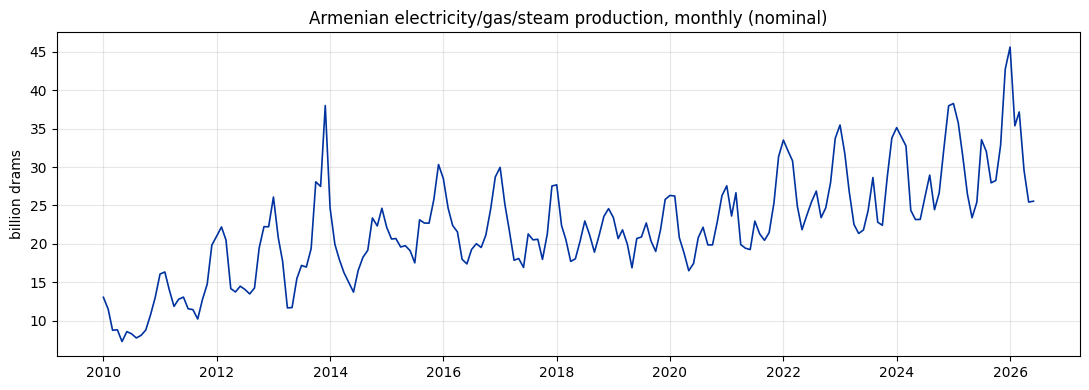

In [3]:
fig, ax = plt.subplots()
ax.plot(series.index, series.values, color=BLUE, lw=1.2)
ax.set_title("Armenian electricity/gas/steam production, monthly (nominal)")
ax.set_ylabel("billion drams")
plt.tight_layout(); plt.show()

Two things jump out:

1. **A strong, regular sawtooth** - that is the seasonality, and it looks stable.
2. **The left-hand end is different.** The first few years rise far faster than anything
   later. Hold that thought; Part 1 is about exactly this.

---
# Part 1 - Audit before you model

The single most valuable step in this project happens **before** any forecasting.

In the interpretability chapter project the first step was a leakage audit. Here it is a
**data-quality audit**, and it works the same way: find the thing that is wrong with the data
*before* you spend the afternoon modelling it.

In [4]:
yearly = series.groupby(series.index.year).sum()
growth = (yearly / yearly.shift(1) - 1) * 100

audit = pd.DataFrame({"total_bn_dram": yearly.round(0), "yoy_pct": growth.round(1)})
audit.loc[2010:2025]

,total_bn_dram,yoy_pct
date,,
2010,114.0,NaN
2011,165.0,43.8
2012,212.0,28.7
2013,251.0,18.3
2014,232.0,-7.5
2015,264.0,13.9
2016,266.0,0.6
2017,259.0,-2.5
2018,259.0,0.1


Read the `yoy_pct` column top to bottom.

**+43.8%, +28.7%, +18.3%** in 2011-2013 - and then it settles into low single digits for a
decade.

National electricity output does not grow 44% in a year. Armenia did not build half a grid
in 2011. So what is this?

Remember what the units are: **current prices**. This series is nominal drams, so it moves when
*either* the physical volume moves *or* the price does. A jump this size, confined to the early
years and then never repeated, is a **tariff or coverage change**, not demand.

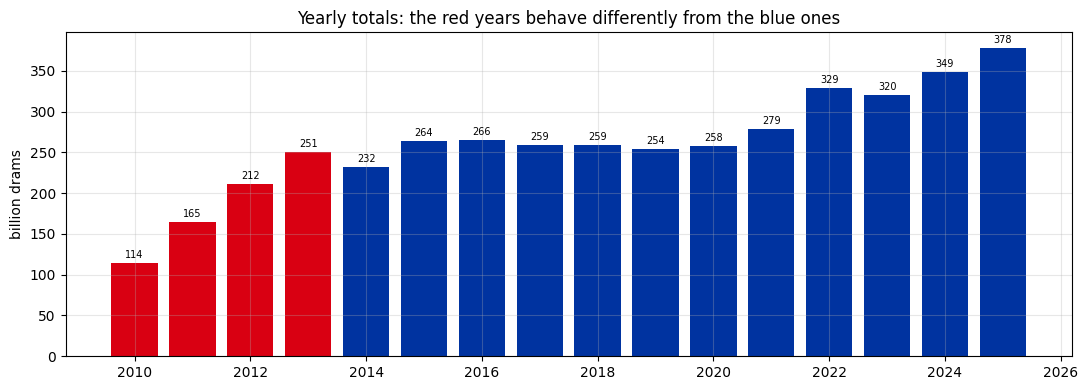

In [5]:
fig, ax = plt.subplots()
colors = [RED if y <= 2013 else BLUE for y in yearly.loc[2010:2025].index]
ax.bar(yearly.loc[2010:2025].index, yearly.loc[2010:2025].values, color=colors)
ax.set_title("Yearly totals: the red years behave differently from the blue ones")
ax.set_ylabel("billion drams")
ax.bar_label(ax.containers[0], fmt="%.0f", fontsize=7, padding=2)
plt.tight_layout(); plt.show()

### The decision

**Cut everything before 2014.** A model fitted through 2010-2013 would learn a steep upward
trend that is an artefact of how the number was recorded, then confidently extrapolate it.

This costs us 4 years of data and is still obviously right. Which is the lesson: *more data is
not better data.*

### One caveat we carry to the end

Even after the cut, this is a **nominal** series. Any "trend" we find mixes real volume growth
with price inflation. So we can honestly say *"production value grows"*; we cannot say
*"Armenia generates more electricity"* - that claim needs a volume series or a deflator, and we
have neither. Say what the data supports, not what sounds better.

In [6]:
s = series[series.index >= "2014-01-01"]
print(f"kept {len(s)} months: {s.index[0]:%Y-%m} .. {s.index[-1]:%Y-%m}")
print(f"dropped {len(series) - len(s)} months from 2010-2013")

kept 150 months: 2014-01 .. 2026-06
dropped 48 months from 2010-2013


---
# Part 2 - Anatomy of the series ([30])

Four components: **trend, seasonality, noise** (and cycles, which we will not separate here).
STL splits the first three apart. `period=12` because the data is monthly.

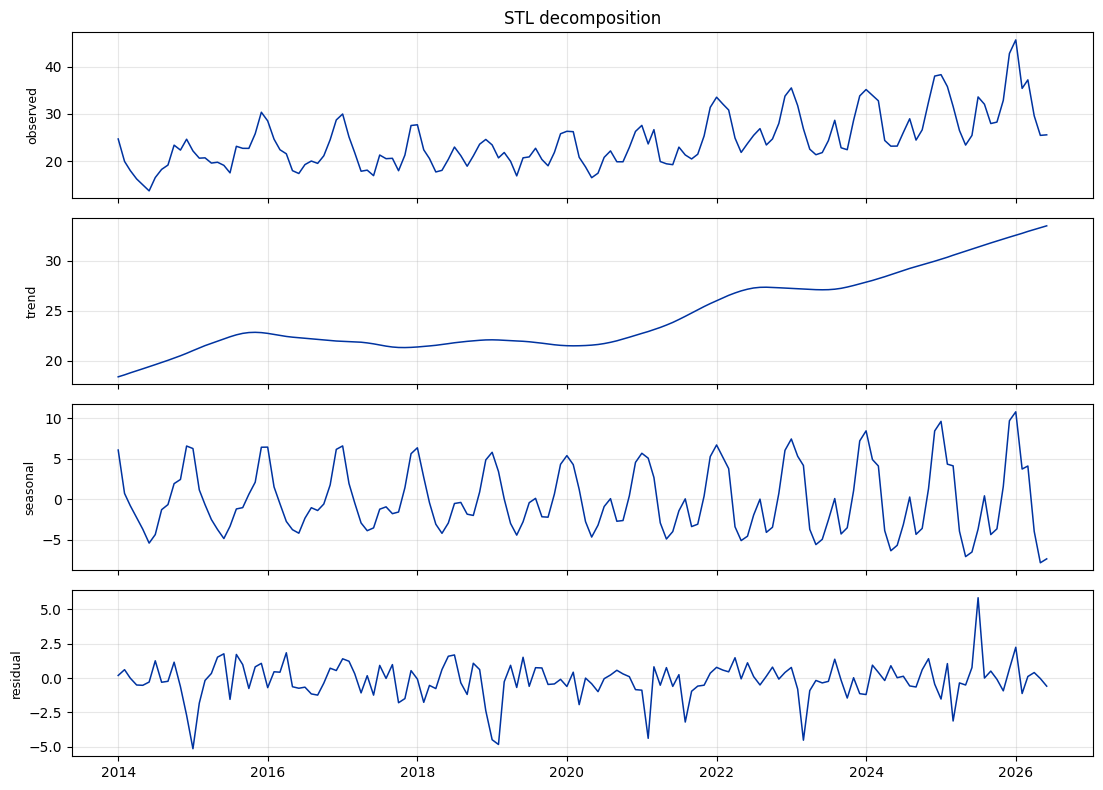

In [7]:
from statsmodels.tsa.seasonal import STL

stl = STL(s, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, (comp, name) in zip(
    axes, [(s, "observed"), (stl.trend, "trend"), (stl.seasonal, "seasonal"), (stl.resid, "residual")]
):
    ax.plot(comp.index, comp.values, color=BLUE, lw=1.1)
    ax.set_ylabel(name, fontsize=9)
axes[0].set_title("STL decomposition")
plt.tight_layout(); plt.show()

The seasonal panel is almost a perfect repeating shape, and the residual panel has no obvious
structure left. That is what a well-behaved seasonal series looks like.

Now check the thing that actually matters for forecasting: **is the seasonal shape stable?**
A seasonal pattern that drifts year to year is much harder to exploit.

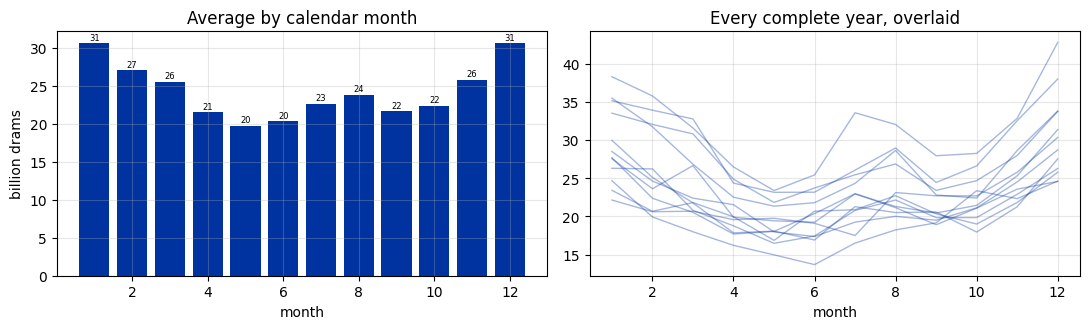

peak month, per year:
date
2014     1
2015    12
2016    12
2017     1
2018     1
2019    12
2020     1
2021    12
2022    12
2023     1
2024    12
2025    12
2026     1

seasonal amplitude: 1.55x (peak 1, trough 5)


In [8]:
month_means = s.groupby(s.index.month).mean()
peak_month = s.groupby(s.index.year).idxmax().map(lambda d: d.month)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(month_means.index, month_means.values, color=BLUE)
axes[0].set_title("Average by calendar month")
axes[0].set_xlabel("month"); axes[0].set_ylabel("billion drams")
axes[0].bar_label(axes[0].containers[0], fmt="%.0f", fontsize=6, padding=1)

for year, grp in s.groupby(s.index.year):
    if len(grp) == 12:
        axes[1].plot(range(1, 13), grp.values, color=BLUE, alpha=0.35, lw=1)
axes[1].set_title("Every complete year, overlaid")
axes[1].set_xlabel("month")
plt.tight_layout(); plt.show()

print("peak month, per year:")
print(peak_month.to_string())
print(f"\nseasonal amplitude: {month_means.max() / month_means.min():.2f}x "
      f"(peak {month_means.idxmax()}, trough {month_means.idxmin()})")

**The peak is December or January in every single year.** Winter heating, and it never moves.

That is unusually clean, and it sets expectations: with seasonality this regular, a method that
simply *copies last year* is going to be hard to beat. Part 4 makes that concrete.

## 2b. Additive or multiplicative?

This is the question the chapter assignment asks first, and it decides real things later - which
Holt-Winters variant to use, and whether to model the series in logs.

- **Additive**: the winter bump is *the same number of drams* every year. Sawtooth of constant height.
- **Multiplicative**: the winter bump is *the same percentage* every year. The sawtooth grows with
  the level.

You cannot settle this by staring at the plot, because the level also grows. Measure it: for each
year, compute the seasonal swing (max - min) and the level (mean). If the swing is additive their
ratio falls as the level rises; if multiplicative, the ratio stays flat.

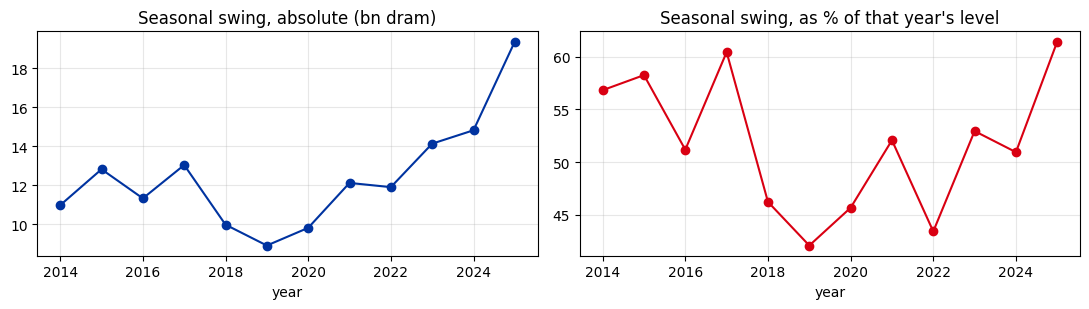

corr(level, absolute swing) = +0.828
corr(level, % swing)        = +0.157


In [9]:
per_year = s.groupby(s.index.year).agg(["mean", "max", "min"])
per_year = per_year[per_year.index < 2026]           # 2026 is a half year, drop it
per_year["swing"] = per_year["max"] - per_year["min"]
per_year["swing_pct"] = per_year["swing"] / per_year["mean"] * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(per_year.index, per_year["swing"], "o-", color=BLUE)
axes[0].set_title("Seasonal swing, absolute (bn dram)")
axes[1].plot(per_year.index, per_year["swing_pct"], "o-", color=RED)
axes[1].set_title("Seasonal swing, as % of that year's level")
for ax in axes:
    ax.set_xlabel("year")
plt.tight_layout(); plt.show()

corr_abs = np.corrcoef(per_year["mean"], per_year["swing"])[0, 1]
corr_pct = np.corrcoef(per_year["mean"], per_year["swing_pct"])[0, 1]
print(f"corr(level, absolute swing) = {corr_abs:+.3f}")
print(f"corr(level, % swing)        = {corr_pct:+.3f}")

### Reading it

The rule: whichever quantity stays **constant** as the level rises is the one the seasonality is
built from, and its correlation with the level should sit near zero.

- `corr(level, absolute swing) = +0.83` - the absolute swing grows strongly with the level.
- `corr(level, % swing) = +0.16` - the percentage swing is close to flat.

So the **percentage** is the stable quantity, and the evidence points to **multiplicative**
seasonality: the winter bump is roughly a fixed *fraction* of that year's level, not a fixed number
of drams.

That is a genuinely useful finding, and it is easy to get backwards by eye - the raw plot in Part 0
looks like a constant sawtooth until you measure it against a rising level.

### So which do we use?

The honest answer is the same one Part 3 will reach about differencing: the diagnostic makes a
recommendation, and the held-out year decides. Holt-Winters can do either, so in Part 5 we fit
**both** `seasonal="add"` and `seasonal="mul"` and compare them on 2025 rather than arguing from
this correlation alone.

---
# Part 3 - Stationarity and differencing ([30])

ARIMA needs a stationary series. Test it - do not eyeball it.

Use **both** ADF and KPSS, because their null hypotheses are opposites:

| Test | H0 | Small p-value means |
|---|---|---|
| ADF | there IS a unit root (non-stationary) | stationary |
| KPSS | the series IS stationary | non-stationary |

Agreement is informative. Disagreement is a warning that you are in a grey zone.

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity(x, label):
    adf_p = adfuller(x.dropna(), autolag="AIC")[1]
    kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[1]
    verdict = ("stationary"      if adf_p < 0.05 and kpss_p > 0.05 else
               "NON-stationary"  if adf_p > 0.05 and kpss_p < 0.05 else
               "tests disagree")
    print(f"{label:28s} ADF p={adf_p:6.3f}   KPSS p={kpss_p:6.3f}   -> {verdict}")

stationarity(s, "raw")

raw                          ADF p= 0.980   KPSS p= 0.010   -> NON-stationary


C:\Users\hayk_\AppData\Local\Temp\ipykernel_15552\2739920265.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[1]


Now difference. Two different jobs, two different operators:

- $(1-B)$ - a **regular** difference, removes the trend.
- $(1-B^{12})$ - a **seasonal** difference, removes the once-a-year pattern.

Apply the seasonal one first and re-test after each step, so we take the *fewest* differences
that do the job.

In [11]:
d_seasonal = s.diff(12)
d_both = d_seasonal.diff(1)

stationarity(s,          "raw")
stationarity(d_seasonal, "(1-B^12)")
stationarity(d_both,     "(1-B^12)(1-B)")

raw                          ADF p= 0.980   KPSS p= 0.010   -> NON-stationary
(1-B^12)                     ADF p= 0.041   KPSS p= 0.073   -> stationary
(1-B^12)(1-B)                ADF p= 0.001   KPSS p= 0.100   -> stationary


C:\Users\hayk_\AppData\Local\Temp\ipykernel_15552\2739920265.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[1]
C:\Users\hayk_\AppData\Local\Temp\ipykernel_15552\2739920265.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[1]


Do not take the p-values on trust - **look at what differencing did.** Stationary means the series
has no trend and roughly constant variance: it should look like noise wobbling around a fixed
level, with no memory of where it started.

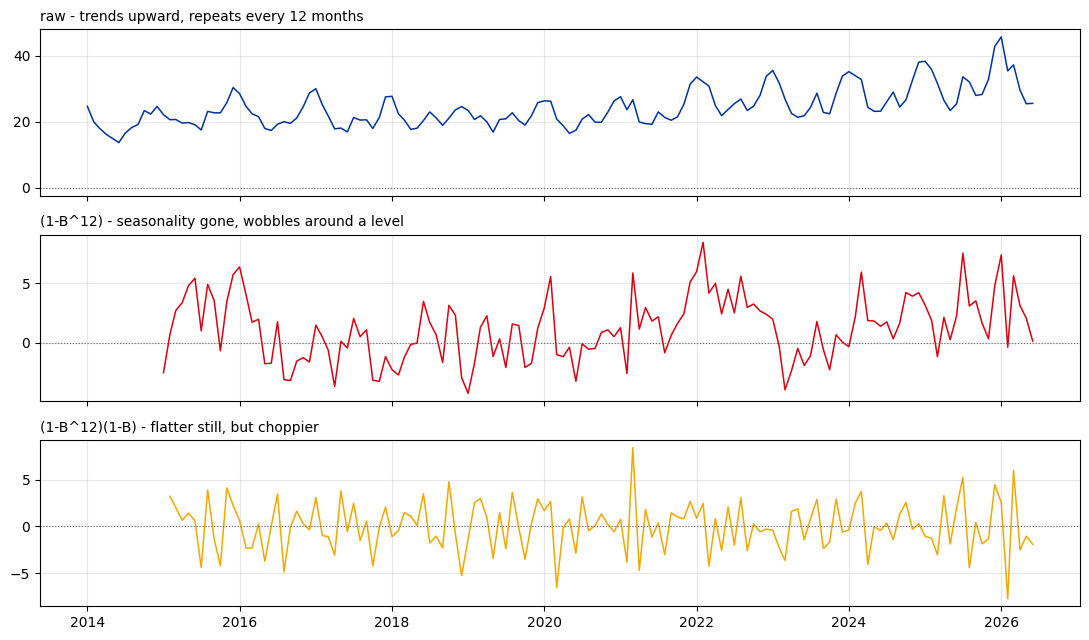

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
for ax, (x, label, col) in zip(axes, [
    (s, "raw - trends upward, repeats every 12 months", BLUE),
    (d_seasonal, "(1-B^12) - seasonality gone, wobbles around a level", RED),
    (d_both, "(1-B^12)(1-B) - flatter still, but choppier", ORANGE),
]):
    ax.plot(x.index, x.values, color=col, lw=1.1)
    ax.axhline(0, color="0.4", lw=0.8, ls=":")
    ax.set_title(label, fontsize=10, loc="left")
plt.tight_layout(); plt.show()

Panel 1 wanders - each year starts where the last ended. That memory is what a unit root *is*.

Panel 2 has lost both the climb and the sawtooth; it oscillates around zero. That is what the test
was telling us.

Panel 3 is flatter again but visibly **choppier** - consecutive points now flip sign more often.
That extra jitter is not information, it is the negative autocorrelation an extra difference
injects. Keep it in mind: it is the cost side of the trade we are about to weigh.

**Stop and read that carefully.** The seasonal difference *alone* already passes both tests.
The regular difference on top of it is not obviously needed.

Over-differencing is a real cost, not a free safety margin: each extra difference inflates the
variance and injects negative autocorrelation that you then have to model away. So check what
each difference actually buys.

In [13]:
for label, x in [("raw", s), ("(1-B^12)", d_seasonal), ("(1-B^12)(1-B)", d_both),
                 ("(1-B^12)(1-B)(1-B)", d_both.diff(1))]:
    print(f"{label:22s} variance = {x.dropna().var():8.2f}")

raw                    variance =    32.41
(1-B^12)               variance =     7.11
(1-B^12)(1-B)          variance =     7.03
(1-B^12)(1-B)(1-B)     variance =    18.88


The seasonal difference does nearly all the work: **32.4 -> 7.1**. Adding the regular difference
takes it from 7.11 to 7.03 - about **1%**, essentially nothing. A third difference nearly triples
the variance, which is the unmistakable signature of over-differencing.

On the evidence so far, $d=0$, $D=1$ looks like the disciplined choice: take the seasonal
difference and stop. Hold onto that conclusion - Part 5 tests it, and the result is not what this
paragraph implies.

We look at both correlograms, because the orders you read depend on which series you read them from.

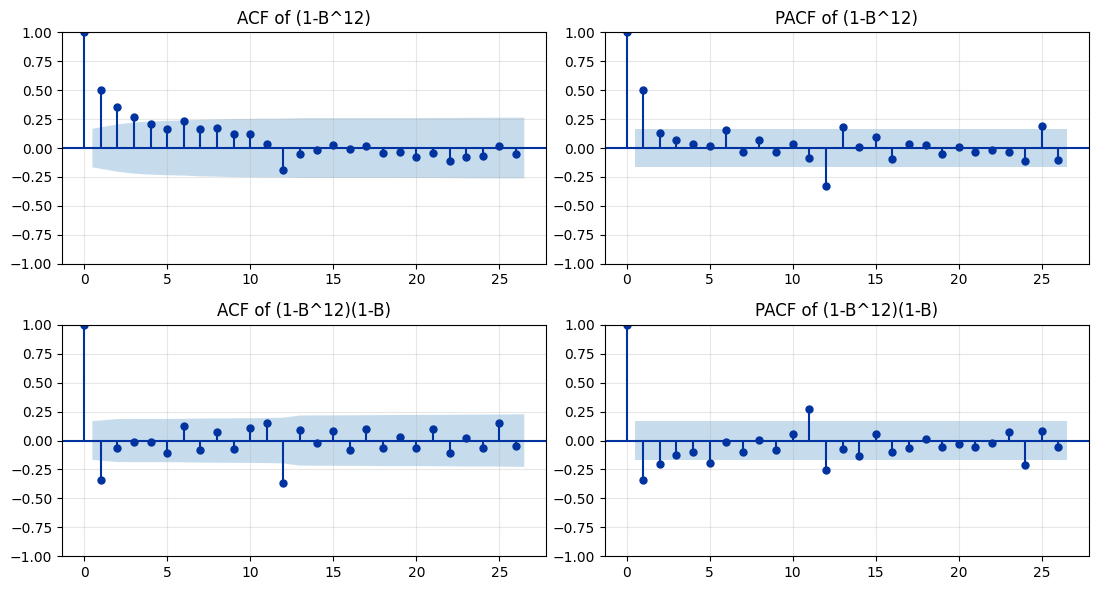

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for row, (x, label) in enumerate([(d_seasonal, "(1-B^12)"), (d_both, "(1-B^12)(1-B)")]):
    plot_acf(x.dropna(), lags=26, ax=axes[row][0], color=BLUE, vlines_kwargs={"colors": BLUE})
    plot_pacf(x.dropna(), lags=26, ax=axes[row][1], method="ywm", color=BLUE,
              vlines_kwargs={"colors": BLUE})
    axes[row][0].set_title(f"ACF of {label}")
    axes[row][1].set_title(f"PACF of {label}")
plt.tight_layout(); plt.show()

### Reading them - and they say different things

**Top row, seasonally differenced only.** The ACF decays gradually (0.54, 0.37, 0.26, 0.23 ...)
while the PACF has one big spike at lag 1 and then nothing until 12. *ACF decays, PACF cuts off*
is the textbook signature of an **AR term**: $p=1$. At lag 12 the PACF is strongly negative
(-0.36), giving a seasonal MA term.

> Reading A: $\text{ARIMA}(1,0,0)(0,1,1)_{12}$

**Bottom row, differenced both ways.** Now the ACF has a single sharp negative spike at lag 1
(-0.31) and another at lag 12 (-0.42), with no slow decay. *ACF cuts off, PACF decays* is the
mirror image - an **MA term** at both scales.

> Reading B: $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ - the classic "airline model"

Both readings are legitimate. They disagree because differencing one extra time *converts* an AR
signature into an MA one - that is what the extra difference did to the data.

So do not argue about it. **Fit both and let the held-out year decide.**

---
# Part 4 - The baseline comes first ([30])

Before any model: **split, then set a naive baseline.** A forecast without a baseline is not a
result, it is a number.

Split by time, never at random. Train ends 2024-12; the whole of 2025 is held out. 2026 is
dropped from both - it is only half a year and would make the seasonal comparison unfair.

In [15]:
train = s[s.index <= "2024-12-01"]
test = s[(s.index >= "2025-01-01") & (s.index <= "2025-12-01")]

print(f"train: {len(train):3d} months  {train.index[0]:%Y-%m} .. {train.index[-1]:%Y-%m}")
print(f"test : {len(test):3d} months  {test.index[0]:%Y-%m} .. {test.index[-1]:%Y-%m}")
print(f"dropped from both: {len(s) - len(train) - len(test)} months of 2026")

train: 132 months  2014-01 .. 2024-12
test :  12 months  2025-01 .. 2025-12
dropped from both: 6 months of 2026


The **seasonal naive** forecast: *whatever happened this month last year.* No parameters, no
fitting. For a 12-month horizon from the end of the training set, that is exactly the 2024
values - so it uses training data only, which makes it a legitimate forecast rather than a peek.

### Predict first

We are about to forecast 2025 by **copying 2024, month for month**. No model, no parameters,
no fitting.

Part 2 showed the peak lands in December or January every single year and the seasonal amplitude
is a steady 1.55x. So before running it:

> *Roughly what percentage error do you expect from "just copy last year"?
> And do you expect a fitted SARIMA to cut that in half?*

Write down two numbers. Then continue.

In [16]:
naive = pd.Series(train[-12:].values, index=test.index, name="seasonal_naive")
naive.round(1)

date
2025-01-01    35.1
2025-02-01    33.9
2025-03-01    32.8
2025-04-01    24.4
2025-05-01    23.2
2025-06-01    23.2
2025-07-01    26.1
2025-08-01    29.0
2025-09-01    24.4
2025-10-01    26.6
2025-11-01    32.5
2025-12-01    38.0
Freq: MS, Name: seasonal_naive, dtype: float64

Plot it against what actually happened.

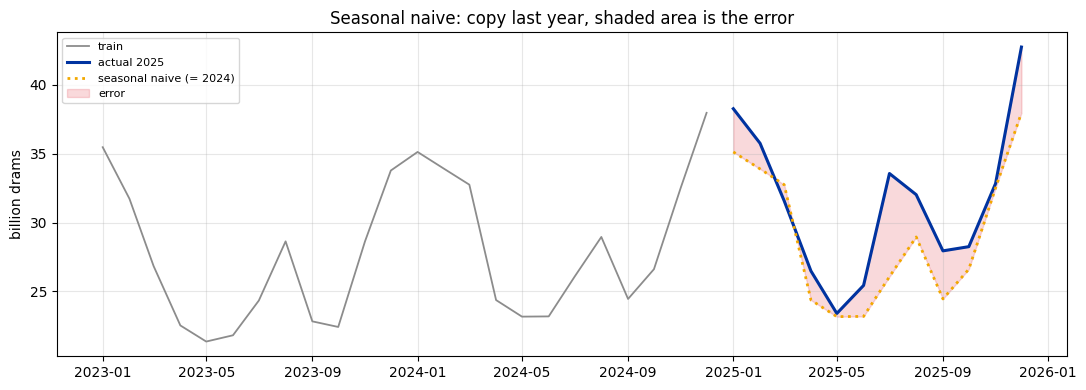

In [17]:
fig, ax = plt.subplots()
ax.plot(train.index[-24:], train.values[-24:], color="0.55", lw=1.3, label="train")
ax.plot(test.index, test.values, color=BLUE, lw=2.2, label="actual 2025")
ax.plot(naive.index, naive.values, color=ORANGE, lw=2, ls=":", label="seasonal naive (= 2024)")
ax.fill_between(test.index, naive.values, test.values, color=RED, alpha=0.15, label="error")
ax.set_title("Seasonal naive: copy last year, shaded area is the error")
ax.set_ylabel("billion drams"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The shape is right - every turn of the year is in roughly the correct place. What is wrong is the
**level**: 2025 sits above 2024 almost everywhere. That is the part a real model can fix, and it
is worth noticing *now* that the seasonal shape is already nearly free.

### MASE, by hand

**MASE** = mean absolute error, divided by the mean absolute error of a seasonal-naive forecast
made *in-sample*. It is the honest scale-free metric here:

- MASE **< 1**: better than naive-would-have-done on the training data.
- MASE **> 1**: worse.

MAPE is reported alongside only because people expect it; it is scale-free too but punishes
errors on small months harder than on large ones, which is not what we want on a seasonal series.

**Step 1 - the errors, one month at a time.** Nothing clever: actual minus forecast, absolute value.

In [18]:
by_hand = pd.DataFrame({
    "actual": test.values,
    "forecast": naive.values,
}, index=test.index.strftime("%Y-%m"))
by_hand["error"] = by_hand["actual"] - by_hand["forecast"]
by_hand["abs_error"] = by_hand["error"].abs()
by_hand.round(2)

,actual,forecast,error,abs_error
date,,,,
2025-01,38.27,35.13,3.14,3.14
2025-02,35.76,33.90,1.86,1.86
2025-03,31.57,32.75,-1.18,1.18
2025-04,26.47,24.36,2.11,2.11
2025-05,23.39,23.16,0.23,0.23
2025-06,25.43,23.17,2.25,2.25
2025-07,33.56,26.06,7.50,7.50
2025-08,32.02,28.95,3.07,3.07
2025-09,27.94,24.44,3.50,3.50


**Step 2 - average them.** That is the MAE, in billions of drams. It is a real, interpretable
quantity: *the typical miss.*

In [19]:
mae_by_hand = by_hand["abs_error"].mean()
print(f"MAE = ({' + '.join(f'{v:.2f}' for v in by_hand['abs_error'][:3])} + ... ) / 12")
print(f"    = {mae_by_hand:.3f} billion drams")

MAE = (3.14 + 1.86 + 1.18 + ... ) / 12
    = 2.633 billion drams


**Step 3 - but is 2.6 billion big?** On its own the number means nothing: it depends entirely on
the units and the size of the series. We need something to divide by.

MASE divides by *how well seasonal-naive would have done inside the training period.* Walk through
the training data, at every point predict "same month last year", and average those errors:

In [20]:
insample_errors = np.abs(train.values[12:] - train.values[:-12])
scale = insample_errors.mean()

print(f"in-sample seasonal-naive errors: {len(insample_errors)} of them")
print(f"first three: {', '.join(f'{v:.2f}' for v in insample_errors[:3])}")
print(f"mean (this is the MASE scale) = {scale:.3f} billion drams")

in-sample seasonal-naive errors: 120 of them
first three: 2.53, 0.69, 2.69
mean (this is the MASE scale) = 2.273 billion drams


**Step 4 - divide.**

$$\text{MASE} = \frac{\text{MAE on the test set}}{\text{MAE of seasonal-naive in the training set}}$$

In [21]:
print(f"MASE = {mae_by_hand:.3f} / {scale:.3f} = {mae_by_hand / scale:.3f}")

MASE = 2.633 / 2.273 = 1.159


Now the number means something, and it is unitless:

- **MASE < 1** - better than seasonal-naive managed on the training data.
- **MASE = 1** - exactly as good.
- **MASE > 1** - worse.

With the arithmetic understood, wrap it in a function so every later model gets scored identically.
MAPE comes along only because people expect it; it is scale-free too, but it punishes errors in
low months harder than in high months, which is the wrong emphasis on a seasonal series.

In [22]:
def score(pred, name):
    err = np.abs(test.values - np.asarray(pred))
    return {"model": name,
            "MAE_bn": err.mean(),
            "MASE": err.mean() / scale,
            "MAPE_%": (err / test.values).mean() * 100}

results = [score(naive, "seasonal naive")]
assert abs(results[0]["MASE"] - mae_by_hand / scale) < 1e-9, "helper disagrees with the hand calc"
pd.DataFrame(results).round(3)

,model,MAE_bn,MASE,MAPE_%
0,seasonal naive,2.633,1.159,8.119


**MASE = 1.16.** Above 1, which is worth pausing on: it means 2025 was *harder* than a typical
year in the training period. The series moved in a way last year's shape did not anticipate.

That is good news for this project - it means there is genuine room to improve, and any model
that gets meaningfully below 1.16 has done real work.

This is the number every model from here on has to beat.

---
# Part 5 - Classical models ([30])

All fitted on `train` only, all forecasting the same 12 months.

First the two SARIMA readings from Part 3, with orders **read from the correlogram** rather than
grid-searched. AIC is reported too, but note it is computed on *differently differenced* series
for the two models, so it is not directly comparable between them - the held-out year is.

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

fits = {}
for name, order, sorder in [("ARIMA(1,0,0)(0,1,1)12", (1, 0, 0), (0, 1, 1, 12)),
                            ("SARIMA(0,1,1)(0,1,1)12", (0, 1, 1), (0, 1, 1, 12))]:
    m = SARIMAX(train, order=order, seasonal_order=sorder,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fits[name] = m
    print(f"{name:24s} AIC = {m.aic:8.2f}")

sarima_a_fc = fits["ARIMA(1,0,0)(0,1,1)12"].forecast(steps=12)
sarima_b_fc = fits["SARIMA(0,1,1)(0,1,1)12"].forecast(steps=12)

ARIMA(1,0,0)(0,1,1)12    AIC =   448.47
SARIMA(0,1,1)(0,1,1)12   AIC =   445.47


### Read the coefficients, do not just collect them

Each term has a plain-language meaning. Print them and say what each one claims about the series.

In [24]:
print(fits["SARIMA(0,1,1)(0,1,1)12"].summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3538      0.098     -3.625      0.000      -0.545      -0.162
ma.S.L12      -0.5760      0.111     -5.185      0.000      -0.794      -0.358
sigma2         3.7997      0.573      6.632      0.000       2.677       4.923


- **`ma.L1`** - the non-seasonal moving-average term. It says this month's value is partly a
  correction of *last month's forecast error*. A large negative value means the series
  over-corrects month to month, which is exactly the choppiness we saw in panel 3 of Part 3.
- **`ma.S.L12`** - the seasonal moving-average term, the same idea one year back: this December
  partly corrects the error made last December. When this sits close to -1, the model is saying
  the seasonal pattern is close to a random walk that needs damping.
- **`sigma2`** - the residual variance. Compare it to the raw variance of 32.4 from Part 3 to see
  how much structure the model actually removed.

The `P>|z|` column is the significance check. A term whose p-value is large is a term you did not
need.

### Residual diagnostics: did the model capture the structure?

A fitted ARIMA makes one strong promise - **the residuals should be white noise.** If any pattern
is left in them, the model missed something and there is more signal on the table.

The Ljung-Box test asks precisely that: is there autocorrelation in the residuals up to some lag?
Its null hypothesis is "no autocorrelation", so here a **large p-value is good news**, which is the
opposite of the usual reflex.

In [25]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = fits["SARIMA(0,1,1)(0,1,1)12"].resid[13:]     # drop the differencing warm-up
lb = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
print(lb.round(4).to_string())
print()
print("large p-value -> residuals look like white noise -> nothing obvious left to model")

    lb_stat  lb_pvalue
6    8.7346     0.1891
12  17.7815     0.1225
24  26.5625     0.3253

large p-value -> residuals look like white noise -> nothing obvious left to model


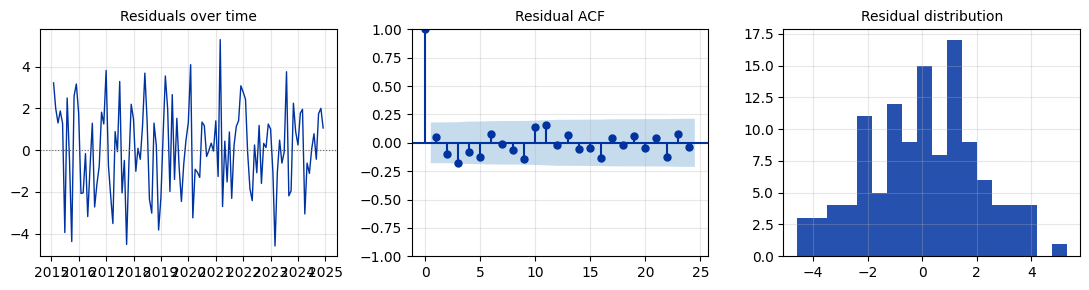

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
axes[0].plot(resid.index, resid.values, color=BLUE, lw=1)
axes[0].axhline(0, color="0.4", lw=0.8, ls=":")
axes[0].set_title("Residuals over time", fontsize=10)
plot_acf(resid, lags=24, ax=axes[1], color=BLUE, vlines_kwargs={"colors": BLUE})
axes[1].set_title("Residual ACF", fontsize=10)
axes[2].hist(resid.values, bins=18, color=BLUE, alpha=0.85)
axes[2].set_title("Residual distribution", fontsize=10)
plt.tight_layout(); plt.show()

What you want to see: no drift or fanning in the first panel, ACF bars inside the blue band in the
second (bar the trivial one at lag 0), and something roughly bell-shaped in the third.

What would worry you: a spike at lag 12 in the ACF - that would mean *seasonal structure the model
failed to absorb*, and the seasonal order needs another look.

Note the honest limit of this check: passing it says the model left no obvious pattern **in the
training data**. It says nothing about 2025. Part 5's punchline is about to make that distinction
very concrete.

Now Holt-Winters, which comes at the problem from a completely different direction: **no
differencing, no correlograms, no stationarity.**

It keeps three running summaries of the series and updates each one every month as new data
arrives, weighting recent observations more heavily than old ones:

| Component | What it tracks | Smoothing parameter |
|---|---|---|
| **Level** | where the series is right now | `alpha` |
| **Trend** | how fast it is climbing | `beta` |
| **Seasonal** | the 12 monthly offsets | `gamma` |

Each parameter runs from 0 to 1 and answers "how much do I trust the newest observation?"

- near **0** - barely react, the component is nearly constant
- near **1** - follow the latest data closely, forget the past quickly

These are **estimated**, not chosen, which makes them worth reading afterwards: the fitted values
tell you what the model concluded about the series. Watch `beta` in particular.

Part 2b said the evidence points to **multiplicative** seasonality, so we fit both variants and
let 2025 settle it - the same discipline we just applied to the two SARIMA readings.

In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_fits = {}
for kind in ("add", "mul"):
    m = ExponentialSmoothing(train, trend="add", seasonal=kind, seasonal_periods=12,
                             initialization_method="estimated").fit()
    hw_fits[kind] = m
    print(f"seasonal={kind}:  alpha={m.params['smoothing_level']:.3f}  "
          f"beta={m.params['smoothing_trend']:.3f}  "
          f"gamma={m.params['smoothing_seasonal']:.3f}  AIC={m.aic:.1f}")

hw_add_fc = hw_fits["add"].forecast(12)
hw_mul_fc = hw_fits["mul"].forecast(12)
hw, hw_fc = hw_fits["add"], hw_add_fc      # kept for the plots below

seasonal=add:  alpha=0.515  beta=0.000  gamma=0.269  AIC=195.3


seasonal=mul:  alpha=0.691  beta=0.000  gamma=0.000  AIC=172.2


`beta` is the trend smoothing parameter. Look at what it came out as before reading on.

In [28]:
results.append(score(sarima_a_fc, "ARIMA(1,0,0)(0,1,1)12"))
results.append(score(sarima_b_fc, "SARIMA(0,1,1)(0,1,1)12"))
results.append(score(hw_add_fc, "Holt-Winters (add)"))
results.append(score(hw_mul_fc, "Holt-Winters (mul)"))
pd.DataFrame(results).round(3)

,model,MAE_bn,MASE,MAPE_%
0,seasonal naive,2.633,1.159,8.119
1,"ARIMA(1,0,0)(0,1,1)12",3.005,1.322,9.236
2,"SARIMA(0,1,1)(0,1,1)12",2.021,0.889,6.761
3,Holt-Winters (add),1.384,0.609,4.342
4,Holt-Winters (mul),1.313,0.578,3.996


Three things worth noticing here.

**Both Holt-Winters variants set `beta` to zero.** Given a trend component, both declined to use
it - they run as level-plus-seasonal models. That independently confirms what the differencing said
in Part 3: strip the seasonal pattern out and there is little systematic trend left in this window.

**The multiplicative variant went further and set `gamma` to zero too.** With `alpha` around 0.69
doing all the work, that model is: *a level that tracks recent months, times a *fixed* seasonal
profile.* It is the simplest thing in this entire notebook - and look where it lands in the table.

**Part 2b's diagnostic was right.** The correlation check predicted multiplicative seasonality, and
the multiplicative fit wins on the held-out year. AIC agrees with it too.

**The two SARIMA readings do not score the same - and the "disciplined" one lost.**

Part 3 argued that $d=0$ was the principled choice: the seasonal difference alone already passed
both stationarity tests, and the extra regular difference reduced variance by about 1%. Every
diagnostic pointed that way.

On the held-out year, `ARIMA(1,0,0)(0,1,1)12` is the **worst model in this entire notebook** -
worse than doing nothing. The airline model, which took the "unnecessary" extra difference, is
among the best. AIC quietly agreed with the airline model too.

This is the lesson, and it is worth more than the forecast:

> Stationarity tests, variance tables and correlograms are **diagnostics, not verdicts**. They
> tell you what the training data looks like. They do not tell you what will forecast well. Only
> held-out evaluation does that, which is why the baseline and the split came first.

A tidy argument that loses out of sample is still a loss. Keep the argument in your notes, and
keep the model the data chose.

### But do not over-learn that either

We have now run the same procedure twice, with opposite outcomes:

| Diagnostic | Its recommendation | Held-out verdict |
|---|---|---|
| Part 2b correlation check | seasonality is **multiplicative** | **confirmed** - `mul` beats `add` |
| Part 3 stationarity + variance | use **d = 0** | **refuted** - it finished last |

So the moral is not "diagnostics are useless". One of them was right, and it saved us from picking
the weaker Holt-Winters. The moral is narrower and more useful:

> A diagnostic tells you what the training data looks like. That is a **hypothesis** about what will
> forecast well, not an answer. It costs one extra fit to check, so check.

The cost of checking here was two extra lines of code. The cost of not checking was, in one of the
two cases, the worst model in the notebook.

---
# Part 6 - Forecasting as supervised learning ([31])

The reframe: build a table where each row is one month, the target is that month's value, and
the features are things **knowable 12 months earlier**. Then it is an ordinary regression
problem and every tool from the rest of the course applies.

### The constraint that shapes everything

We forecast **12 months ahead**. So at prediction time for 2025-07 we know nothing after
2024-12. Any feature built from lag 1..11 would be *unavailable* - using it is leakage.

The clean fix: **use only lags of 12 or more.** That makes this a direct 12-step forecast, with
no recursive feeding of predictions back in.

### First, see the problem concretely

Stand at the end of the training data, **2024-12**. We must forecast all twelve months of 2025 from
there, so the binding case is the **furthest** one: December 2025, a full 12 months out.

In [29]:
standing_at = pd.Timestamp("2024-12-01")

for target_month in (pd.Timestamp("2025-07-01"), pd.Timestamp("2025-12-01")):
    print(f"forecasting {target_month:%Y-%m}, standing at {standing_at:%Y-%m}:")
    for lag in (1, 6, 11, 12, 24):
        needed = target_month - pd.DateOffset(months=lag)
        have = needed <= standing_at
        print(f"   lag_{lag:<2d} needs {needed:%Y-%m}  ->  "
              f"{'available' if have else 'NOT YET OBSERVED'}")
    print()

forecasting 2025-07, standing at 2024-12:
   lag_1  needs 2025-06  ->  NOT YET OBSERVED
   lag_6  needs 2025-01  ->  NOT YET OBSERVED
   lag_11 needs 2024-08  ->  available
   lag_12 needs 2024-07  ->  available
   lag_24 needs 2023-07  ->  available

forecasting 2025-12, standing at 2024-12:
   lag_1  needs 2025-11  ->  NOT YET OBSERVED
   lag_6  needs 2025-06  ->  NOT YET OBSERVED
   lag_11 needs 2025-01  ->  NOT YET OBSERVED
   lag_12 needs 2024-12  ->  available
   lag_24 needs 2023-12  ->  available



Compare the two blocks, because they disagree - and the disagreement *is* the lesson.

For **July 2025** even `lag_11` is fine: it reaches back to 2024-08, which we have. If July were
the only target, short lags would be perfectly legal.

For **December 2025** everything below `lag_12` is a value nobody has yet. And since one model has
to serve the whole horizon, the *hardest* month sets the rule for all of them:

> At a horizon of $h$ months, only lags of $h$ or more are safe.

Putting `lag_1` in this model would be leakage. It would score beautifully in cross-validation and
be unusable in reality, because when you forecast December 2025 nobody has November 2025's number.

So: **lags of 12 or more only.** That also makes this a *direct* forecast - one model that jumps
straight to 12 months ahead - rather than a *recursive* one that predicts 1 month, feeds its own
prediction back in, and repeats 12 times. More on that trade-off at the end of this part.

### Now build the features, one family at a time

**Family 1 - lags.** The raw "what was it N months ago" values.

In [30]:
feat = pd.DataFrame({"y": s})
for lag in (12, 13, 14, 18, 24):
    feat[f"lag_{lag}"] = s.shift(lag)

feat.loc["2016-01":"2016-03"].round(1)

,y,lag_12,lag_13,lag_14,lag_18,lag_24
date,,,,,,
2016-01-01,28.5,22.1,24.6,22.3,16.5,24.7
2016-02-01,24.6,20.6,22.1,24.6,18.2,19.9
2016-03-01,22.4,20.7,20.6,22.1,19.2,18.0


Read one row: for 2016-01, `lag_12` is 2015-01 and `lag_24` is 2014-01 - the same month in
previous years. Those are the most informative single numbers we have, because the series is
strongly seasonal.

**Family 2 - rolling summaries.** A single lag is noisy; an average over a window is steadier.
The `.shift(12)` **before** `.rolling(12)` is the part that matters - it guarantees the window
closes at least 12 months before the row it describes.

In [31]:
feat["roll12_mean"] = s.shift(12).rolling(12).mean()
feat["roll12_std"] = s.shift(12).rolling(12).std()
feat["yoy_diff_12_24"] = s.shift(12) - s.shift(24)

feat.loc["2016-01":"2016-03", ["y", "lag_12", "roll12_mean", "roll12_std", "yoy_diff_12_24"]].round(2)

,y,lag_12,roll12_mean,roll12_std,yoy_diff_12_24
date,,,,,
2016-01-01,28.50,22.15,19.10,3.47,-2.53
2016-02-01,24.63,20.62,19.16,3.49,0.69
2016-03-01,22.40,20.69,19.38,3.49,2.69


`roll12_mean` is the level of the year ending 12 months ago; `roll12_std` is how volatile that year
was; `yoy_diff_12_24` is the change between the two previous same-months, which is the closest
thing to a **trend** signal we can legally give the model.

That last one matters more than it looks - hold onto it for Part 7.

**Family 3 - calendar.** The month number itself, plus a trick.

In [32]:
feat["month"] = feat.index.month
feat["month_sin"] = np.sin(2 * np.pi * feat["month"] / 12)
feat["month_cos"] = np.cos(2 * np.pi * feat["month"] / 12)
feat["t"] = np.arange(len(feat))

feat.loc["2016-11":"2017-02", ["month", "month_sin", "month_cos"]].round(3)

,month,month_sin,month_cos
date,,,
2016-11-01,11,-0.500,0.866
2016-12-01,12,-0.000,1.000
2017-01-01,1,0.500,0.866
2017-02-01,2,0.866,0.500


Why `sin` and `cos` rather than just the month number? Because **December and January are
neighbours**, but as plain integers 12 and 1 are as far apart as possible. A model splitting on
`month <= 6` cuts the year at an arbitrary seam.

Map the month onto a circle and that seam disappears: December and January land next to each other,
which is what the physical calendar actually does. Look at the rows above - the `sin`/`cos` pair
changes smoothly across the year boundary while `month` jumps from 12 to 1.

`t` is a plain time index. We include it deliberately, because Part 7 is about what a tree does
with it.

In [33]:
feat = feat.dropna()
print(f"{len(feat)} usable rows, {feat.shape[1] - 1} features")
print(f"first usable month: {feat.index[0]:%Y-%m}  (24 months lost to the longest lag)")
print(f"\nfeature names: {', '.join(c for c in feat.columns if c != 'y')}")

126 usable rows, 12 features
first usable month: 2016-01  (24 months lost to the longest lag)

feature names: lag_12, lag_13, lag_14, lag_18, lag_24, roll12_mean, roll12_std, yoy_diff_12_24, month, month_sin, month_cos, t


Note the cost that just got paid: **24 months are gone** because the longest lag needs two years of
history before it can be computed. Every feature you add with a longer window shortens the usable
table. On 150 months that is not free.

Split the feature table by the same dates as before, so every model is judged on the same 12
months.

In [34]:
FEATURES = [c for c in feat.columns if c != "y"]
tr = feat[feat.index <= "2024-12-01"]
te = feat[(feat.index >= "2025-01-01") & (feat.index <= "2025-12-01")]
X_tr, y_tr = tr[FEATURES], tr["y"]
X_te, y_te = te[FEATURES], te["y"]
print(f"train rows {len(tr)}, test rows {len(te)}")

train rows 108, test rows 12


### Why a random split would lie to you

Shuffle these rows and a June 2025 row lands in training while May 2025 sits in test. The model
then "predicts" the past from the future. `TimeSeriesSplit` respects the arrow of time: every
fold trains strictly before it tests.

`gap=11` on top of that, because our features only start at lag 12 - without a gap the fold
boundary would let the model validate on months it effectively already saw.

In [35]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4, test_size=12, gap=11)
for i, (a, b) in enumerate(tscv.split(X_tr), 1):
    print(f"fold {i}: train {tr.index[a[0]]:%Y-%m}..{tr.index[a[-1]]:%Y-%m}  "
          f"({len(a):3d} rows)   ->   test {tr.index[b[0]]:%Y-%m}..{tr.index[b[-1]]:%Y-%m}")

fold 1: train 2016-01..2020-01  ( 49 rows)   ->   test 2021-01..2021-12
fold 2: train 2016-01..2021-01  ( 61 rows)   ->   test 2022-01..2022-12
fold 3: train 2016-01..2022-01  ( 73 rows)   ->   test 2023-01..2023-12
fold 4: train 2016-01..2023-01  ( 85 rows)   ->   test 2024-01..2024-12


Now fit gradient boosting on those features. Small model on purpose: ~130 training rows cannot
support anything large.

In [36]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=7,
                    min_child_samples=8, subsample=0.9, colsample_bytree=0.9,
                    random_state=SEED, n_jobs=4, verbose=-1)
lgb.fit(X_tr, y_tr)
lgb_fc = pd.Series(lgb.predict(X_te), index=te.index)

results.append(score(lgb_fc, "LightGBM (lag>=12)"))
pd.DataFrame(results).round(3)

,model,MAE_bn,MASE,MAPE_%
0,seasonal naive,2.633,1.159,8.119
1,"ARIMA(1,0,0)(0,1,1)12",3.005,1.322,9.236
2,"SARIMA(0,1,1)(0,1,1)12",2.021,0.889,6.761
3,Holt-Winters (add),1.384,0.609,4.342
4,Holt-Winters (mul),1.313,0.578,3.996
5,LightGBM (lag>=12),2.406,1.059,7.231


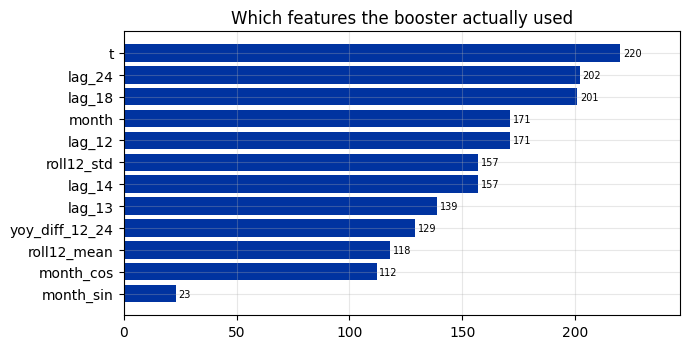

In [37]:
imp = pd.Series(lgb.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(imp.index, imp.values, color=BLUE)
ax.bar_label(ax.containers[0], fmt="%.0f", fontsize=7, padding=2)
ax.set_title("Which features the booster actually used")
ax.margins(x=0.12)
plt.tight_layout(); plt.show()

Worth reading rather than admiring. LightGBM's default importance counts **how often** a feature
was split on, which rewards features with many usable cut points - a continuous lag will always
look busier than a 12-valued `month`. So read it as "what the trees kept reaching for", not as
"what matters".

Compare this with the interpretability chapter: this is impurity-style importance, and [23] spent
a lecture on why that measure is biased. Permutation importance on the test window would be the
honest version - though with 12 test points it would be extremely noisy.

### Direct vs recursive, and why we chose direct

There are two ways to forecast 12 months ahead, and the deck names both:

| | How it works | Cost |
|---|---|---|
| **Recursive** | Train one 1-step model. Predict month 1, append that prediction, predict month 2 from it, repeat. | Errors **compound** - by step 12 you are forecasting from eleven of your own guesses. |
| **Direct** | Train a model whose features are all >= 12 months old, so it jumps straight to the answer. | No compounding, but the model never sees recent months, so it throws away information. |

We used **direct**, and the honest reason is that it makes the leakage question trivial: if no
feature is younger than 12 months, no forecast can accidentally use the future. Recursive would be
defensible too, and would probably do better at short horizons.

A third option, used in practice, is to train **12 separate direct models**, one per horizon. That
is often the strongest and it costs 12x the fitting.

---
# Part 7 - The extrapolation trap ([31])

### Predict first

Suppose we throw away the lag features and hand the booster the **time index** `t` and the
month, on the **raw level** series, which trends upward for a decade.

*Before running the next cell: what will the 2025 forecast look like?*

Commit to an answer.

In [38]:
naive_features = ["t", "month"]
trap = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=7,
                     min_child_samples=8, random_state=SEED, n_jobs=4, verbose=-1)
trap.fit(X_tr[naive_features], y_tr)
trap_fc = pd.Series(trap.predict(X_te[naive_features]), index=te.index)

print(f"highest value seen in training : {y_tr.max():.1f} bn dram")
print(f"highest value it ever predicts : {trap_fc.max():.1f} bn dram")
print(f"actual highest value in 2025   : {y_te.max():.1f} bn dram")

highest value seen in training : 38.0 bn dram
highest value it ever predicts : 35.6 bn dram
actual highest value in 2025   : 42.8 bn dram


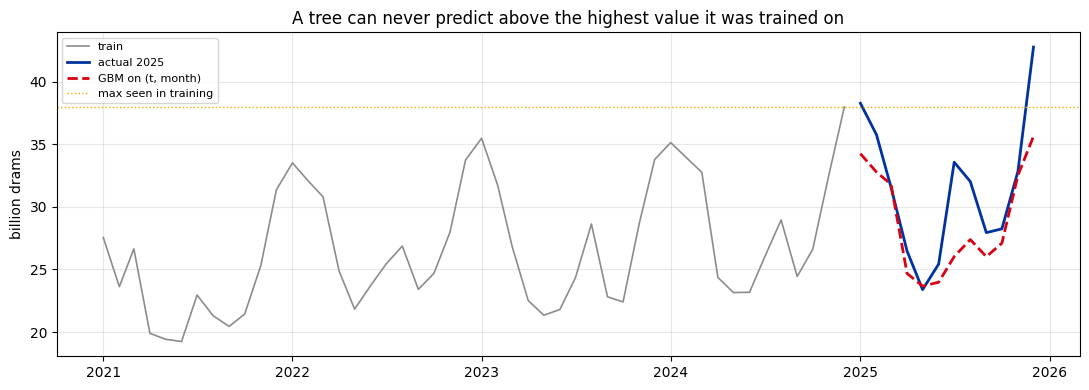

In [39]:
fig, ax = plt.subplots()
ax.plot(train.index[-48:], train.values[-48:], color="0.55", lw=1.2, label="train")
ax.plot(test.index, test.values, color=BLUE, lw=2, label="actual 2025")
ax.plot(trap_fc.index, trap_fc.values, color=RED, lw=2, ls="--", label="GBM on (t, month)")
ax.axhline(y_tr.max(), color=ORANGE, lw=1, ls=":", label="max seen in training")
ax.set_title("A tree can never predict above the highest value it was trained on")
ax.set_ylabel("billion drams"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Why

A tree predicts by **averaging training targets in a leaf**. Every leaf value is an average of
numbers it has seen, so no prediction can ever exceed the training maximum. Feed it `t` and it
splits on `t <= something`; every future month falls into the same right-most leaf and gets the
same answer. The forecast goes flat.

Linear regression would extrapolate happily here. Trees cannot. This is not a tuning problem and
no amount of `n_estimators` fixes it.

### Two ways out

1. **Difference first**, so the target has no trend to extrapolate - then add the level back.
2. **Give it lag features** instead of a raw time index, so "where the series currently is"
   arrives as an input rather than something it has to invent. That is what Part 6 did.

Here is fix 1, on the same trap features.

In [40]:
# model the year-over-year CHANGE, then add last year's level back
y_tr_diff = y_tr - X_tr["lag_12"]

fixed = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=7,
                      min_child_samples=8, random_state=SEED, n_jobs=4, verbose=-1)
fixed.fit(X_tr[naive_features], y_tr_diff)
fixed_fc = pd.Series(fixed.predict(X_te[naive_features]) + X_te["lag_12"].values, index=te.index)

results.append(score(trap_fc, "GBM on (t, month) - TRAP"))
results.append(score(fixed_fc, "GBM on differences"))
pd.DataFrame(results).round(3)

,model,MAE_bn,MASE,MAPE_%
0,seasonal naive,2.633,1.159,8.119
1,"ARIMA(1,0,0)(0,1,1)12",3.005,1.322,9.236
2,"SARIMA(0,1,1)(0,1,1)12",2.021,0.889,6.761
3,Holt-Winters (add),1.384,0.609,4.342
4,Holt-Winters (mul),1.313,0.578,3.996
5,LightGBM (lag>=12),2.406,1.059,7.231
6,"GBM on (t, month) - TRAP",2.788,1.227,8.234
7,GBM on differences,1.832,0.806,5.798


Differencing turns a catastrophic model into a competitive one, using **the same algorithm and
the same two features**. The fix was the target, not the model.

---
# Part 8 - Honest comparison ([31])

Every model, one horizon (12 months), one test window (2025), one baseline.

In [41]:
table = pd.DataFrame(results).set_index("model").sort_values("MASE")
table["vs_naive_%"] = ((table["MASE"] / table.loc["seasonal naive", "MASE"]) - 1) * 100
table.round(3)

,MAE_bn,MASE,MAPE_%,vs_naive_%
model,,,,
Holt-Winters (mul),1.313,0.578,3.996,-50.142
Holt-Winters (add),1.384,0.609,4.342,-47.434
GBM on differences,1.832,0.806,5.798,-30.424
"SARIMA(0,1,1)(0,1,1)12",2.021,0.889,6.761,-23.266
LightGBM (lag>=12),2.406,1.059,7.231,-8.636
seasonal naive,2.633,1.159,8.119,0.000
"GBM on (t, month) - TRAP",2.788,1.227,8.234,5.894
"ARIMA(1,0,0)(0,1,1)12",3.005,1.322,9.236,14.102


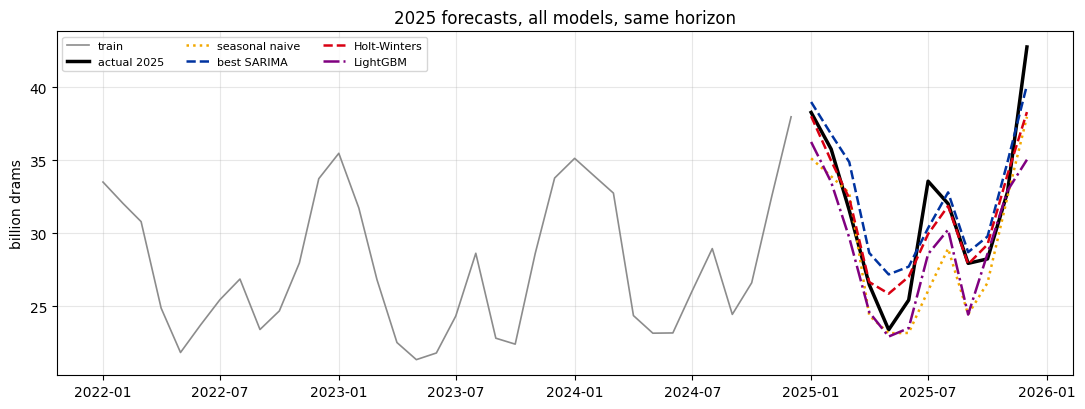

In [42]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(train.index[-36:], train.values[-36:], color="0.55", lw=1.2, label="train")
ax.plot(test.index, test.values, color="black", lw=2.5, label="actual 2025")
for (name, fc), col, ls in [(("seasonal naive", naive), ORANGE, ":"),
                            (("best SARIMA", sarima_a_fc if score(sarima_a_fc, "")["MASE"]
                              < score(sarima_b_fc, "")["MASE"] else sarima_b_fc), BLUE, "--"),
                            (("Holt-Winters", hw_fc), RED, "--"),
                            (("LightGBM", lgb_fc), "purple", "-.")]:
    ax.plot(test.index, np.asarray(fc), color=col, ls=ls, lw=1.8, label=name)
ax.set_title("2025 forecasts, all models, same horizon")
ax.set_ylabel("billion drams"); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

### Where did they go wrong? A single MASE hides the answer.

Break the error down month by month. A model that is uniformly a bit off is a very different
animal from one that is perfect for ten months and catastrophic in two.

In [43]:
all_fc = pd.DataFrame({
    "seasonal naive": naive.values,
    "SARIMA(0,1,1)(0,1,1)12": np.asarray(sarima_b_fc),
    "Holt-Winters (add)": np.asarray(hw_add_fc),
    "Holt-Winters (mul)": np.asarray(hw_mul_fc),
    "LightGBM (lag>=12)": lgb_fc.values,
    "GBM on differences": fixed_fc.values,
}, index=test.index)

monthly_err = all_fc.sub(test.values, axis=0)          # signed: + means over-forecast
monthly_err.index = monthly_err.index.strftime("%b")
monthly_err.round(2)

,seasonal naive,"SARIMA(0,1,1)(0,1,1)12",Holt-Winters (add),Holt-Winters (mul),LightGBM (lag>=12),GBM on differences
date,,,,,,
Jan,-3.14,0.71,-0.26,0.07,-2.02,-1.13
Feb,-1.86,1.03,-0.80,-1.38,-2.26,0.54
Mar,1.18,3.31,0.83,0.54,-1.87,4.41
Apr,-2.11,2.17,0.18,0.52,-1.88,-0.29
May,-0.23,3.79,2.47,1.73,-0.46,1.57
Jun,-2.25,2.28,1.59,0.40,-1.92,-0.54
Jul,-7.50,-3.21,-3.62,-4.83,-4.99,-5.79
Aug,-3.07,0.78,-0.16,-1.43,-1.78,-0.85
Sep,-3.50,0.77,-0.05,-0.18,-3.51,-1.27


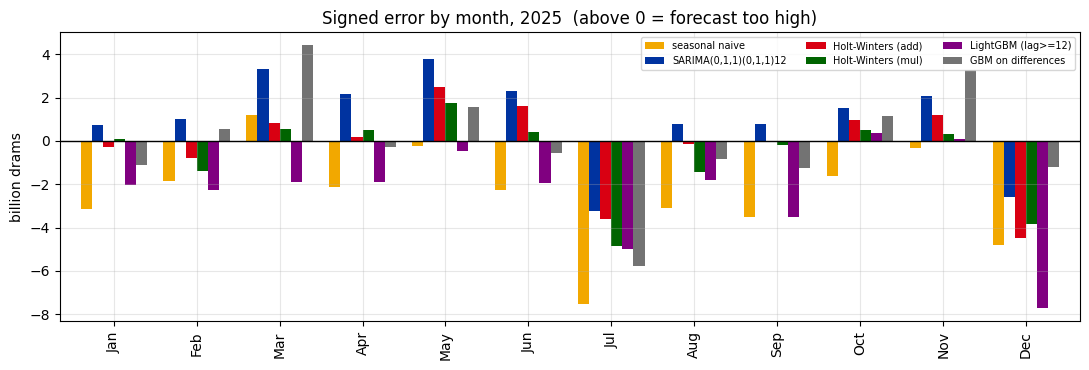

In [44]:
fig, ax = plt.subplots(figsize=(11, 3.8))
monthly_err.plot(kind="bar", ax=ax, width=0.8,
                 color=[ORANGE, BLUE, RED, "darkgreen", "purple", "0.45"])
ax.axhline(0, color="black", lw=1)
ax.set_title("Signed error by month, 2025  (above 0 = forecast too high)")
ax.set_ylabel("billion drams"); ax.set_xlabel("")
ax.legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

In [45]:
summary = pd.DataFrame({
    "mean_signed_error": monthly_err.mean(),
    "worst_month": monthly_err.abs().idxmax(),
    "worst_error": monthly_err.abs().max(),
})
summary.round(2)

,mean_signed_error,worst_month,worst_error
seasonal naive,-2.44,Jul,7.50
"SARIMA(0,1,1)(0,1,1)12",1.05,May,3.79
Holt-Winters (add),-0.17,Dec,4.46
Holt-Winters (mul),-0.63,Jul,4.83
LightGBM (lag>=12),-2.33,Dec,7.72
GBM on differences,-0.01,Jul,5.79


### What the breakdown shows

Look at **`mean_signed_error`** first. If a model's errors were random noise this would sit near
zero. A clearly negative value means the model **under-forecast almost every month** - it got the
seasonal shape right and the level wrong, which is a *bias*, not bad luck.

That is the seasonal-naive story from Part 4 in one number: copying 2024 misses everything that
made 2025 different from 2024.

Now look at **`worst_month`**. If several models miss in the *same* month, that month contained
something none of them could have known - and no amount of model tuning would have helped. That is
a data point about the world, not about the models.

In [46]:
best = table.index[0]
spread = table["MASE"].max() - table["MASE"].min()
beat = (table["MASE"] < table.loc["seasonal naive", "MASE"]).sum()
print(f"best model                     : {best}  (MASE {table.loc[best, 'MASE']:.3f})")
print(f"models that beat the baseline  : {beat} of {len(table)}")
print(f"MASE spread across all models  : {spread:.3f}")
print(f"test set size                  : {len(test)} months")

best model                     : Holt-Winters (mul)  (MASE 0.578)
models that beat the baseline  : 5 of 8
MASE spread across all models  : 0.744
test set size                  : 12 months


---
# Part 9 - Verdict

### What we can say

Read the table above, not this sentence - the notebook is executed, so the numbers are real and
they, not the prose, are the result.

### Why the winner won

Holt-Winters is the simplest model in the comparison and it beat everything, including gradient
boosting. That is not luck, and the explanation is sitting in its own fitted parameters.

Four separate pieces of evidence, gathered independently, all said the same thing about this series:

1. Part 2: the seasonal shape is **extremely stable** - peak in December or January, all 16 years.
2. Part 2b: the swing is a stable **percentage** of the level, i.e. multiplicative.
3. Part 3: after the seasonal difference the series was **already stationary** - no trend left.
4. Part 5: both Holt-Winters variants estimated **`beta` = 0.000**, and the multiplicative one set
   **`gamma` = 0.000** as well. Offered trend and seasonal adaptation, it took neither.

Put those together and the series is: *a level that drifts slowly, times a fixed seasonal profile,
plus noise.* The winning model is precisely that and nothing more - one active parameter.

Its assumptions match the data, so every parameter it has goes into the part that matters.

The booster, by contrast, spent its capacity learning a seasonal shape that Holt-Winters gets for
free from its structure - and it had roughly 120 rows to do it with.

**The general lesson: on short, strongly structured series, a model whose assumptions match the
data beats a flexible model that has to learn the structure from scratch.** More capacity is not
more accuracy when there is not enough data to feed it.

### What we cannot say

**The test set is 12 points.** That is one draw of one year. A MASE gap of a few hundredths
between two models on 12 observations is not evidence that one method is better than the other;
it is noise with a decimal point. Reporting it as a ranking would be exactly the overclaiming
this course keeps warning about.

To make a real claim you would need rolling-origin evaluation: refit at many cut points and
compare the *distribution* of errors, not one number each.

### What actually generalises

1. **Audit first.** The 2011-2013 artefact was worth more than any model choice here. Had we
   kept it, every model would have inherited a trend that was never real.
2. **The baseline is the result.** Seasonal naive scored MASE 1.16 with zero parameters. On a
   series with a peak this regular, that is a genuinely hard target - and knowing *how hard* is
   what tells you whether a fancy model earned its complexity.
3. **Diagnostics are not verdicts.** Part 3 built a clean case for $d=0$ from two stationarity
   tests and a variance table, and Part 5 showed that model finishing last. Every in-sample
   diagnostic describes the training data; only the held-out year speaks about forecasting. When
   the two disagree, the held-out year wins.
4. **Trees cannot extrapolate.** Part 7 is a property of the model class, not a bug, and the fix
   is to change what you ask it to predict.
5. **Say the horizon out loud.** Everything here is 12 months ahead. None of it transfers to a
   1-month-ahead problem without being re-measured.
6. **The units limit the claim.** Nominal drams. We measured production *value*, and cannot
   separate volume from price.

### If you want to take it further

- Rolling-origin evaluation, as above - the single biggest upgrade to the honesty of the result.
- Deflate by CPI (ArmStatBank has monthly CPI back to 1993) and redo it on real terms. Does the
  trend survive?
- Add temperature as an exogenous regressor - `SARIMAX` takes one, and heating demand should
  respond to it.
- Try the same pipeline on a sector with a real shock. `13. Manufacture of textiles` in the same
  armstat table fell about 29% in 2020, and everything here will behave differently.